# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [40]:
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/v46/txs156/"
repobase = "/home/156/txs156/uom/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

# Import the PartialConv2d layer from om2_model_utils module
from om2_model_utils import PartialConv2d

In [41]:
# Normalisation strategies - Global in time and space; 
#                            per grid over all times; 
#                            per grid over months (climatology)

## Setup PyEarthTools data accessor and pipeline

In [51]:
# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

# Keep one explicit time window so all normalisation paths are directly comparable.
normalisation_window = dict(start='2000-01', end='2018-12', interval='1 month')
normalised_variables = ["ocean_heat_content_2d", "total_surface_heat_flx"]

# NEW: use the in-built PET normaliser now that ACCESS_OHC inherits ArchiveIndex.
# `deviation_spatial` means: compute mean/std per grid-point over time.
normalisation = petdata.transforms.normalisation.Normalise(
    ACCESS_OHC_accessor,
    start=normalisation_window['start'],
    end=normalisation_window['end'],
    interval=normalisation_window['interval'],
)

In [64]:
print(normalised_variables[1])

global_mean_stats, global_std_stats = global_normalisation.get_deviation(
    variable_name=normalised_variables[],
    spatial=False,
)
spatial_mean_stats, spatial_std_stats = global_normalisation.get_deviation(
    variable_name=normalised_variables[],
    spatial=True,
)

total_surface_heat_flx


In [2]:
# Helper used to fix cell-2 Deviation(...) construction errors:
# PET can return stats in multiple container forms (Dataset/DataArray/path/dict),
# while pipeline Deviation expects concrete xarray objects or file paths.
def _coerce_stats_to_dataset(stats_obj, variables):
    if isinstance(stats_obj, xr.Dataset):
        ds = stats_obj
    elif isinstance(stats_obj, xr.DataArray):
        ds = stats_obj.to_dataset()
    elif isinstance(stats_obj, (str, Path)):
        ds = xr.open_dataset(stats_obj)
    elif isinstance(stats_obj, dict):
        # Handle dict outputs like {var: path_or_dataset} robustly.
        parts = []
        for key, value in stats_obj.items():
            if isinstance(value, xr.Dataset):
                part = value
            elif isinstance(value, xr.DataArray):
                part = value.to_dataset(name=key)
            elif isinstance(value, (str, Path)):
                part = xr.open_dataset(value)
            else:
                part = xr.Dataset({key: value})
            parts.append(part)
        ds = xr.merge(parts)
    else:
        ds = xr.Dataset(stats_obj)

    keep = [v for v in variables if v in ds.data_vars]
    if keep:
        ds = ds[keep]
    return ds

# NEW: extract PET-computed mean/std once and reuse them in torch so both paths
# (pipeline and torch) are based on the exact same statistics.
raw_mean_stats, raw_std_stats = grid_over_time_normaliser.get_deviation(
    variable_name=normalised_variables[0],
    spatial=True,
)

# Coerce to xarray datasets so Deviation(...) does not misinterpret objects as files.
mean_grid_over_time_ds = _coerce_stats_to_dataset(raw_mean_stats, normalised_variables)
std_grid_over_time_ds = _coerce_stats_to_dataset(raw_std_stats, normalised_variables)

# Raw pipeline (no normalisation):
# Keep this as the training data source and do mode selection inside torch so
# one training loop can switch between both requested normalisation options.
full = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
    petpipe.operations.xarray.values.FillNan(0),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
    iterator=petpipe.iterators.DateRange('2000-06', '2001-01', interval='1 month')
)

# Optional PET pipeline reference for grid-over-time normalisation.
# NOTE: We do not iterate this path in this notebook because xarray->numpy conversion
# can fail when coordinate alignment introduces mixed/duplicate coordinate sizes.
full_grid_over_time = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
    # Use Evaluated instead of Deviation so PET does not try to parse
    # mean/std as backend-loaded files in this runtime environment.
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=mean_grid_over_time_ds,
        deviation=std_grid_over_time_ds,
    ),
    petpipe.operations.xarray.values.FillNan(0),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
    iterator=petpipe.iterators.DateRange('2000-06', '2001-01', interval='1 month')
)

ipipe = iter(full)  # First raw sample used for setup/debug visual checks.
full.exceptions_to_ignore
n = next(ipipe)

# We intentionally skip iter(full_grid_over_time) here to avoid converter failures
# on mixed coordinate metadata; instead we build an equivalent reference below
# from PET-derived mean/std arrays after they are assembled.

# Build channel-aligned mean/std arrays for torch branch from PET stats.
mean_grid_over_time = np.stack(
    [mean_grid_over_time_ds[v].values.astype(np.float32) for v in normalised_variables],
    axis=0,
)  # (C, H, W)
std_grid_over_time = np.stack(
    [std_grid_over_time_ds[v].values.astype(np.float32) for v in normalised_variables],
    axis=0,
)  # (C, H, W)

# Build a grid-over-time normalised reference sample directly in numpy using
# the same PET-derived statistics; this is equivalent to pipeline deviation.
n_grid_over_time = (
    (n - mean_grid_over_time[np.newaxis, :, :, :])
    / (std_grid_over_time[np.newaxis, :, :, :] + 1e-6)
)
n_grid_over_time = np.where(np.isfinite(n_grid_over_time), n_grid_over_time, 0.0).astype(np.float32)

# Keep mask derivation from source data so land points stay excluded from metrics/loss.
ds_mask = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
mask_xr = xr.where(np.isnan(ds_mask.total_surface_heat_flx.isel(time=0)), 0, 1)
mask = mask_xr.values

/opt/conda/envs/pet/lib/python3.11/site-packages/dask/array/numpy_compat.py:57: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


## Do some checks - input data and partial convolutions

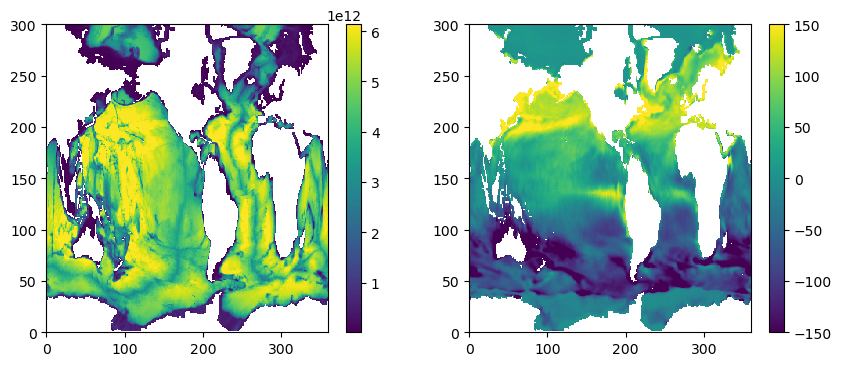

In [3]:
# Quick check to see if things look reasonable:
QNET = np.where(mask, n[0,0,:,:], np.nan)
OHC = np.where(mask, n[0,1,:,:], np.nan)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

pcm0 = axes[0].pcolormesh(OHC)
pcm1 = axes[1].pcolormesh(QNET, vmin=-150, vmax=150)

fig.colorbar(pcm0, ax=axes[0])
fig.colorbar(pcm1, ax=axes[1])

Input shape: torch.Size([1, 1, 300, 360])
Input Mask shape: torch.Size([1, 1, 300, 360])
Output shape: torch.Size([1, 1, 150, 180])
New Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796296296296
New valid fraction: 0.6898888945579529


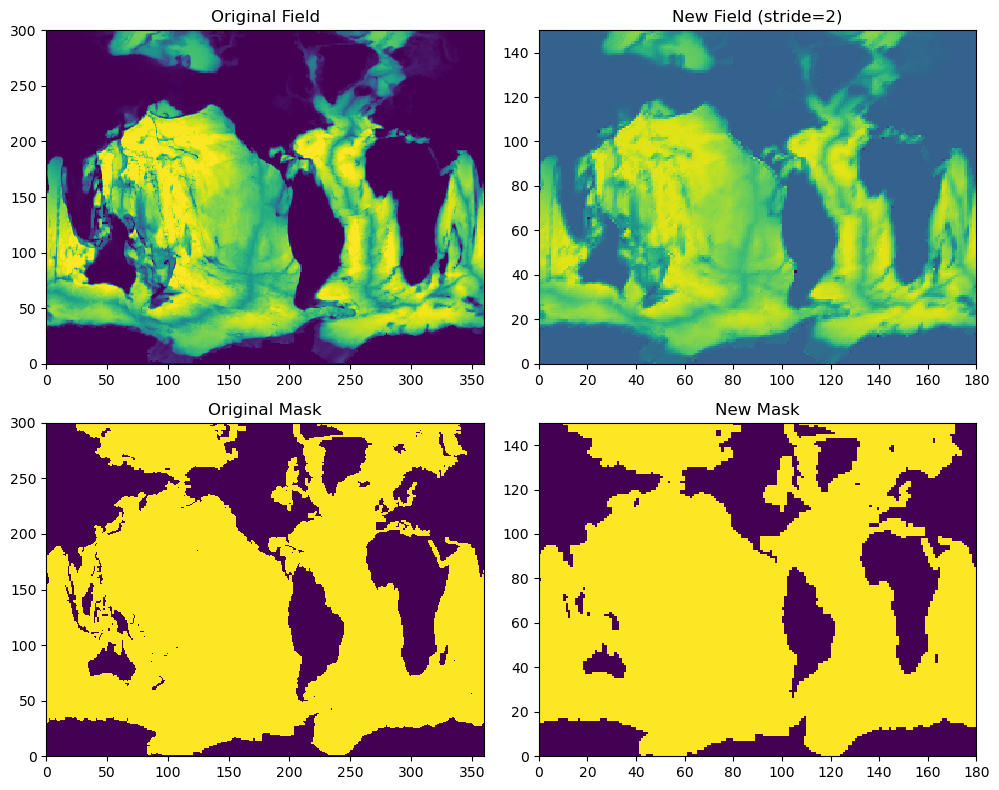

In [4]:
# Test Partial Convolution:
# convert to tensors
field = n[0,1,:,:]  # Take the first variable (OHC) for the first time step
x = torch.tensor(field, dtype=torch.float32)
mask_t = torch.tensor(mask, dtype=torch.float32)  # Explicit .values to extract numpy array
x = x.unsqueeze(0).unsqueeze(0)
mask_t = mask_t.unsqueeze(0).unsqueeze(0)

# Do an example convolution:
layer = PartialConv2d(in_ch=1,out_ch=1,kernel_size=3,stride=2,padding=1)
out, new_mask = layer(x, mask_t)

print("Input shape:", x.shape)
print("Input Mask shape:", mask_t.shape)
print("Output shape:", out.shape)
print("New Mask shape:", new_mask.shape)

# Convert tensors → numpy
new_field = out.detach().squeeze().numpy()
new_mask  = new_mask.detach().squeeze().numpy()

# Fractions covered by ocean:
print("Original valid fraction:", mask.mean().item())
print("New valid fraction:", new_mask.mean().item())

# Plot the results:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
im0 = axes[0,0].pcolormesh(field)
axes[0,0].set_title("Original Field")
im1 = axes[1,0].pcolormesh(mask)
axes[1,0].set_title("Original Mask")
im2 = axes[0,1].pcolormesh(new_field)
axes[0,1].set_title("New Field (stride=2)")
im3 = axes[1,1].pcolormesh(new_mask)
axes[1,1].set_title("New Mask")
plt.tight_layout()
plt.show()

## Define the model

In [5]:
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)
        reconstructed = self.sigmoid(x)
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed

## Initialize model and prepare data for training

In [26]:
# Initialize a lightweight model instance for quick smoke tests in the next cell.
# Full training models are created per normalisation mode in the training cell below.
model = AutoEncoder(input_channel_count=n.shape[1], output_channel_count=n.shape[1]).to(device)

# Keep criterion declaration for consistency with previous notebook workflow.
criterion = nn.L1Loss()

# Convert numpy -> tensor for one reference sample used in normalisation diagnostics.
x = torch.from_numpy(n).float().to(device)

# Prepare mask with shape [1, 1, H, W] so it broadcasts over [T, C, H, W].
# We use ocean mask values so land points are excluded from normalisation/loss.
mask_t = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).float().to(device)

# Promote PET-derived (deviation_spatial) mean/std to tensors with shape [1, C, H, W]
# for broadcast against [T, C, H, W] in the grid-over-time mode.
mean_grid_over_time_t = torch.from_numpy(mean_grid_over_time).float().unsqueeze(0).to(device)
std_grid_over_time_t = torch.from_numpy(std_grid_over_time).float().unsqueeze(0).to(device)

def normalise_per_gridpoint_over_all_times(x, mean_ref, std_ref, mask_t=None, eps=1e-6):
    """Normalise with per-gridpoint mean/std computed over all times."""
    # Keep stats on the same dtype/device as x to avoid implicit copies/conversions.
    mean = mean_ref.to(device=x.device, dtype=x.dtype)
    std = std_ref.to(device=x.device, dtype=x.dtype)

    # NEW: explicitly ignore NaNs (and invalid stats) independent of pipeline FillNan.
    # This keeps behaviour robust even if raw data or cached statistics contain NaNs.
    valid = torch.isfinite(x) & torch.isfinite(mean) & torch.isfinite(std)
    if mask_t is not None:
        valid = valid & (mask_t > 0)

    # Replace invalid values before arithmetic so normalisation stays finite.
    x_safe = torch.where(torch.isfinite(x), x, torch.zeros_like(x))
    mean_safe = torch.where(torch.isfinite(mean), mean, torch.zeros_like(mean))
    std_safe = torch.where(torch.isfinite(std), std, torch.ones_like(std))

    # Clamp std to prevent unstable divisions where local variance is ~0.
    std_safe = torch.clamp(std_safe, min=eps)

    # Apply z-score with PET-equivalent spatial statistics.
    x_norm = (x_safe - mean_safe) / (std_safe + eps)

    # Zero invalid points so NaNs/land do not leak into model input/loss.
    x_norm = torch.where(valid, x_norm, torch.zeros_like(x_norm))

    return x_norm, mean_safe, std_safe

def normalise_per_timestep_over_all_gridpoints(x, mask_t=None, eps=1e-6):
    """Normalise each time-step using spatial (H, W) mean/std per channel."""
    # Valid points must be finite and (if provided) ocean-only via mask.
    valid = torch.isfinite(x)
    if mask_t is not None:
        valid = valid & (mask_t > 0)

    valid_f = valid.float()

    # Replace invalid values before reduction so means/variances are controlled.
    x_safe = torch.where(valid, x, torch.zeros_like(x))

    # Compute per (T, C) statistics across gridpoints only (H, W).
    count = valid_f.sum(dim=(2, 3), keepdim=True).clamp_min(1.0)
    mean = (x_safe * valid_f).sum(dim=(2, 3), keepdim=True) / count
    var = ((x_safe - mean) ** 2 * valid_f).sum(dim=(2, 3), keepdim=True) / count
    std = torch.sqrt(var + eps)

    # Apply timestep-wise z-score and zero invalid points after transform.
    x_norm = (x_safe - mean) / (std + eps)
    x_norm = torch.where(valid, x_norm, torch.zeros_like(x_norm))

    return x_norm, mean, std

def normalise_original_global_zscore(x, mask_t=None, eps=1e-6):
    """Use the original legacy z-score exactly as in the earlier notebook."""
    if mask_t is None:
        raise ValueError("original_global_zscore requires mask_t to match the legacy formula")

    # Original normalization ignoring NaNs / masked land points:
    mean = (x * mask_t).mean(dim=(0, 2, 3), keepdim=True)  # (1, C, 1, 1)
    var = torch.mean((x * mask_t - mean) ** 2.0, dim=(0, 2, 3), keepdim=True)
    std = torch.sqrt(var + eps)
    x_norm = (x * mask_t - mean) / (std + eps)
    # x_norm = torch.nan_to_num(x_norm, nan=0.0)

    return x_norm, mean, std

def apply_normalisation_mode(x, normalisation_mode, mask_t=None):
    """Single dispatch point for all supported normalisation modes."""
    if normalisation_mode == "grid_over_time":
        return normalise_per_gridpoint_over_all_times(
            x,
            mean_ref=mean_grid_over_time_t,
            std_ref=std_grid_over_time_t,
            mask_t=mask_t,
        )
    if normalisation_mode == "timestep_over_grid":
        return normalise_per_timestep_over_all_gridpoints(x, mask_t=mask_t)
    if normalisation_mode == "original_global_zscore":
        return normalise_original_global_zscore(x, mask_t=mask_t)
    raise ValueError(f"Unknown normalisation_mode={normalisation_mode}")

# Define the three modes to compare throughout training and diagnostics.
NORMALISATION_MODES = [
    "grid_over_time",
    "timestep_over_grid",
    "original_global_zscore",
]

# Build one reference normalised sample per mode so we can inspect differences early.
x_norm_by_mode = {}
mean_by_mode = {}
std_by_mode = {}
for mode in NORMALISATION_MODES:
    x_norm_mode, mean_mode, std_mode = apply_normalisation_mode(x, mode, mask_t=mask_t)
    x_norm_by_mode[mode] = x_norm_mode
    mean_by_mode[mode] = mean_mode
    std_by_mode[mode] = std_mode

# Cross-check PET parity for grid_over_time: torch path vs PET-stats-derived numpy reference.
x_norm_grid_over_time_pipeline = torch.from_numpy(n_grid_over_time).float().to(device)
pipeline_match_mae = torch.mean(
    torch.abs(x_norm_by_mode["grid_over_time"] - x_norm_grid_over_time_pipeline)
).item()
print(f"Grid-over-time check MAE (torch vs PET-stats reference): {pipeline_match_mae:.6f}")

# Report pairwise differences between all requested modes.
for i, mode_a in enumerate(NORMALISATION_MODES):
    for mode_b in NORMALISATION_MODES[i + 1:]:
        diff = x_norm_by_mode[mode_a] - x_norm_by_mode[mode_b]
        mae = torch.mean(torch.abs(diff)).item()
        rmse = torch.sqrt(torch.mean(diff ** 2)).item()
        print(f"MAE {mode_a} vs {mode_b}: {mae:.6f}")
        print(f"RMSE {mode_a} vs {mode_b}: {rmse:.6f}")

# Keep one explicit default mode for single-run smoke-test cells.
normalisation_mode = "original_global_zscore"
x_in = x_norm_by_mode[normalisation_mode]
mean = mean_by_mode[normalisation_mode]
std = std_by_mode[normalisation_mode]


Grid-over-time check MAE (torch vs PET-stats reference): 0.000000
MAE grid_over_time vs timestep_over_grid: 42713100288.000000
RMSE grid_over_time vs timestep_over_grid: 128861503488.000000
MAE grid_over_time vs original_global_zscore: 42713100288.000000
RMSE grid_over_time vs original_global_zscore: 128861503488.000000
MAE timestep_over_grid vs original_global_zscore: 0.436743
RMSE timestep_over_grid vs original_global_zscore: 0.559266


Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


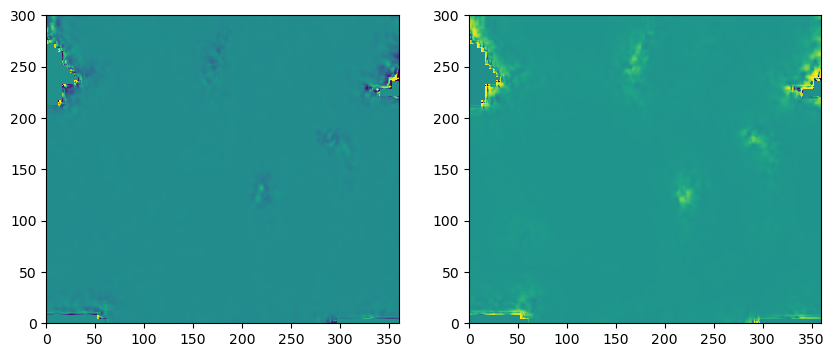

In [28]:
# Test model forward pass with untrained weights:
prediction = model(x_in, mask_t)
print("Input shape:", x_in.shape)
print("Mask shape:", mask_t.shape)
print("Prediction shape:", prediction.shape)

image_numpy_for_display = prediction.to('cpu').detach().numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pcolormesh(image_numpy_for_display[0][0])
axes[1].pcolormesh(image_numpy_for_display[0][1])
plt.show()

## Training loop

In [29]:
%%time

def train_single_mode(
    normalisation_mode,
    debug=False,
    num_epochs=1,
    max_samples=10,
    print_per=20,
    learning_rate=1e-4,
):
    """Train one model for one normalisation mode and return comparable outputs."""
    # Re-initialise model/optimizer per mode so each run is independent and fair.
    model_mode = AutoEncoder(input_channel_count=n.shape[1], output_channel_count=n.shape[1]).to(device)
    optimizer_mode = optim.Adam(model_mode.parameters(), lr=learning_rate)

    sample_ix = 0
    epoch_losses = []

    for epoch in range(num_epochs):
        total_loss = 0.0
        epoch_samples = 0

        # Iterate raw (unnormalised) data; normalisation is selected per mode below.
        ipipe = iter(full)

        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break
            except Exception:
                # Some dates may be missing from source archive; skip and continue.
                continue

            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(f"{normalisation_mode}: processed {epoch_samples} samples in epoch {epoch + 1}")

            if sample_ix > max_samples:
                break

            if debug:
                print(f"{normalisation_mode} sample {sample_ix}")

            x_batch = torch.from_numpy(sample).float().to(device)

            # Apply the selected normalisation mode.
            x_norm, _, _ = apply_normalisation_mode(x_batch, normalisation_mode, mask_t=mask_t)

            optimizer_mode.zero_grad()

            # Forward pass.
            y_batch = model_mode(x_norm, mask_t)

            # Masked MAE keeps loss evaluation on ocean points only.
            diff = torch.abs(y_batch - x_norm)
            loss = (diff * mask_t).sum() / mask_t.sum().clamp_min(1.0)

            if debug:
                print("loss", float(loss.detach().cpu().item()))

            # Backward pass and optimisation step.
            loss.backward()
            optimizer_mode.step()

            total_loss += float(loss.detach().cpu().item())

        # Track epoch-average loss per mode.
        avg_loss = total_loss / max(epoch_samples, 1)
        epoch_losses.append(avg_loss)
        print(f"{normalisation_mode} | Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

    # Evaluate each mode on the same fixed reference sample for direct comparison.
    x_eval = torch.from_numpy(n).float().to(device)
    x_eval_norm, mean_eval, std_eval = apply_normalisation_mode(x_eval, normalisation_mode, mask_t=mask_t)

    with torch.no_grad():
        prediction_eval = model_mode(x_eval_norm, mask_t)

        # Convert back to physical units using mode-consistent mean/std.
        prediction_phys = prediction_eval[:, :x_eval_norm.shape[1]] * (std_eval + 1e-6) + mean_eval
        input_phys = x_eval_norm[:, :x_eval_norm.shape[1]] * (std_eval + 1e-6) + mean_eval

        # Save latent representation for mode-by-mode latent-space plots.
        latent_eval, _ = model_mode.encode(x_eval_norm, mask_t)

    return {
        "model": model_mode,
        "epoch_losses": epoch_losses,
        "x_in": x_eval_norm.detach().cpu(),
        "mean": mean_eval.detach().cpu(),
        "std": std_eval.detach().cpu(),
        "prediction_display": prediction_phys.detach().cpu().numpy(),
        "input_display": input_phys.detach().cpu().numpy(),
        "latent": latent_eval[0].detach().cpu().numpy(),
    }

# Train one independent model for each normalisation mode requested.
results_by_mode = {}
for mode in NORMALISATION_MODES:
    print(f"\n=== Training mode: {mode} ===")
    results_by_mode[mode] = train_single_mode(
        normalisation_mode=mode,
        debug=False,
        num_epochs=100,
        max_samples=15 * 1000,
        print_per=500,
        learning_rate=1e-4,
    )

# Keep one selected mode as convenience alias for any single-mode follow-up cells.
selected_mode_for_detail = "timestep_over_grid"
selected_result = results_by_mode[selected_mode_for_detail]
model = selected_result["model"]
x_in = selected_result["x_in"].to(device)
mean = selected_result["mean"].to(device)
std = selected_result["std"].to(device)



=== Training mode: grid_over_time ===
grid_over_time | Epoch [1/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [2/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [3/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [4/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [5/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [6/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [7/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [8/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [9/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [10/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [11/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [12/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [13/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [14/100] Average Loss: 132162610322.2857
grid_over_time | Epoch [15/100] Average Loss: 132162610322.2857
grid_over_

## Compute final prediction

In [30]:
# Gather prediction/input displays for each mode from stored training results.
# This cell keeps backward-compatible single-mode aliases while exposing per-mode data.
prediction_display_by_mode = {
    mode: results_by_mode[mode]["prediction_display"]
    for mode in NORMALISATION_MODES
}
input_display_by_mode = {
    mode: results_by_mode[mode]["input_display"]
    for mode in NORMALISATION_MODES
}

# Backward-compatible aliases for the selected mode.
prediction_display = prediction_display_by_mode[selected_mode_for_detail]
input_display = input_display_by_mode[selected_mode_for_detail]


## Diagnostics

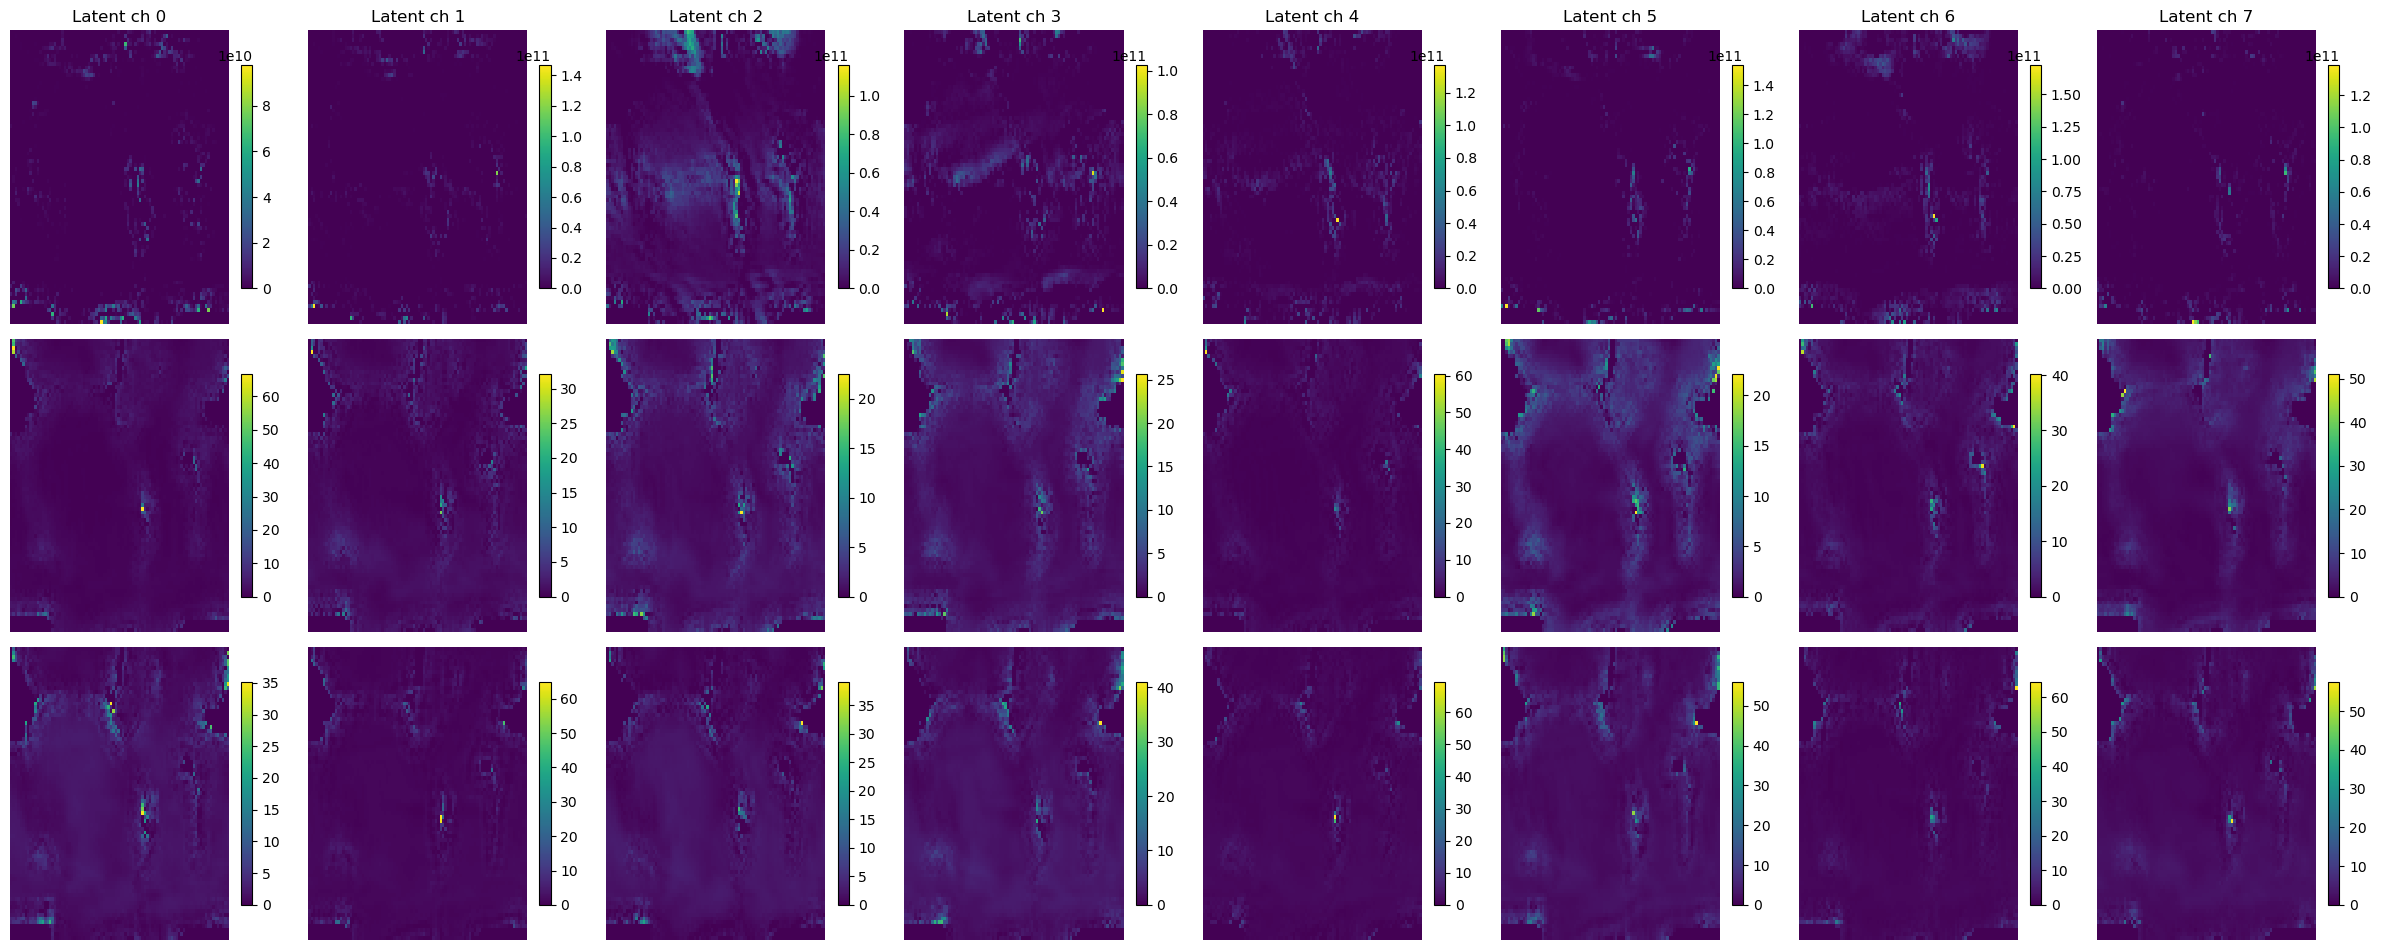

In [31]:
## Inspect Latent Space (all normalisation modes)

# Compare latent channels mode-by-mode on the same reference sample.
n_latent_show = min(8, min(results_by_mode[mode]["latent"].shape[0] for mode in NORMALISATION_MODES))

fig, axs = plt.subplots(len(NORMALISATION_MODES), n_latent_show, figsize=(3 * n_latent_show, 3.2 * len(NORMALISATION_MODES)))

# Normalise axis handling for the single-row edge case.
if len(NORMALISATION_MODES) == 1:
    axs = np.expand_dims(axs, axis=0)

for row, mode in enumerate(NORMALISATION_MODES):
    z = results_by_mode[mode]["latent"]  # (C_latent, H_latent, W_latent)
    for col in range(n_latent_show):
        ax = axs[row, col]
        im = ax.pcolormesh(z[col], cmap="viridis")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Latent ch {col}")
        if col == 0:
            ax.set_ylabel(mode)
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


In [32]:
## Compute RMSE (all normalisation modes)

# Shared area weights for fair spatially weighted RMSE across all modes.
ds = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)
area_weighted = area_t * mask

RMSE_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    # Channel convention in this notebook:
    # [0] = OHC, [1] = total_surface_heat_flx
    err_ohc = pred[0, 0] - obs[0, 0]
    err_sfx = pred[0, 1] - obs[0, 1]

    rmse_ohc = np.sqrt(np.nansum(err_ohc**2 * area_weighted) / np.nansum(area_weighted))
    rmse_sfx = np.sqrt(np.nansum(err_sfx**2 * area_weighted) / np.nansum(area_weighted))

    RMSE_by_mode[mode] = {
        "heat_flux": float(rmse_sfx),
        "ohc": float(rmse_ohc),
    }

    print(f"{mode} | RMSE heat_flux: {rmse_sfx:.6e}, RMSE OHC: {rmse_ohc:.6e}")

# Backward-compatible RMSE list for selected mode only.
RMSE = [
    RMSE_by_mode[selected_mode_for_detail]["heat_flux"],
    RMSE_by_mode[selected_mode_for_detail]["ohc"],
]


grid_over_time | RMSE heat_flux: 4.509905e+12, RMSE OHC: 4.510279e+12
timestep_over_grid | RMSE heat_flux: 1.307092e+12, RMSE OHC: 7.668806e+01
original_global_zscore | RMSE heat_flux: 1.052167e+12, RMSE OHC: 8.045276e+01


/g/data/v46/txs156/vscode-tmp/ipykernel_1763063/3810120630.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


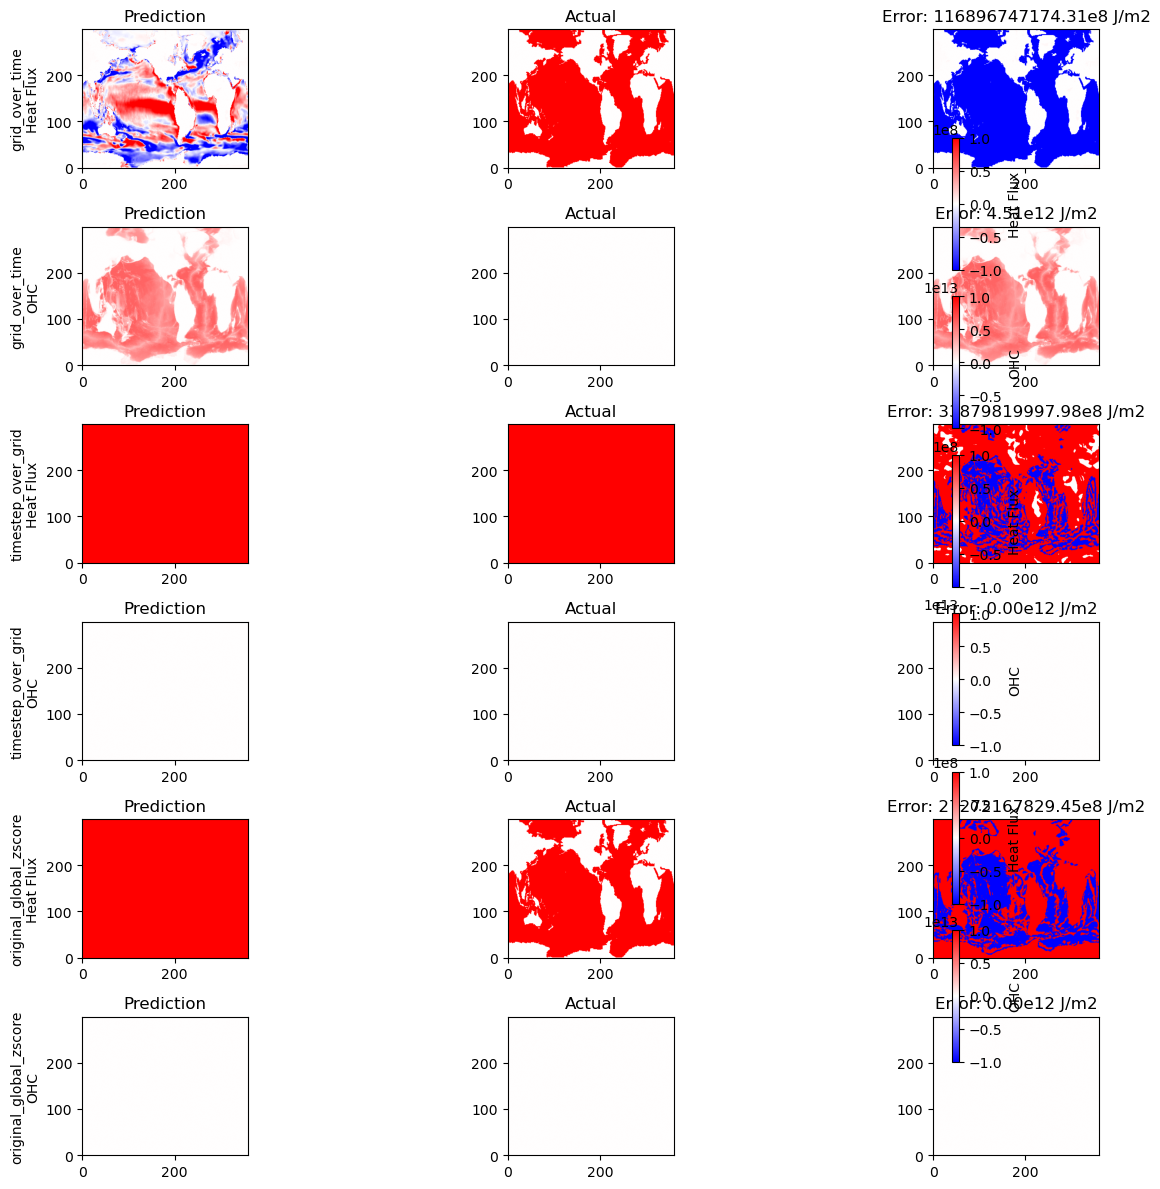

In [33]:
import matplotlib.pyplot as plt

# Spatial-map comparison for every normalisation mode:
# two rows per mode (heat flux and OHC), three columns (prediction, actual, error).
num_modes = len(NORMALISATION_MODES)
fig, axes = plt.subplots(nrows=2 * num_modes, ncols=3, figsize=(14, 4 * num_modes))

# Ensure 2D indexing works even in edge cases.
if 2 * num_modes == 1:
    axes = np.expand_dims(axes, axis=0)

for mode_idx, mode in enumerate(NORMALISATION_MODES):
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    # ----- Heat Flux row -----
    row_h = 2 * mode_idx
    pred_h = pred[0, 1] * (30 * 24 * 3600)
    obs_h = obs[0, 1] * (30 * 24 * 3600)
    err_h = pred_h - obs_h

    im_h_pred = axes[row_h, 0].imshow(pred_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 1].imshow(obs_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 2].imshow(err_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)

    for c in range(3):
        axes[row_h, c].invert_yaxis()

    axes[row_h, 0].set_ylabel(f"{mode}\nHeat Flux")
    axes[row_h, 0].set_title("Prediction")
    axes[row_h, 1].set_title("Actual")
    axes[row_h, 2].set_title(
        "Error: {:.2f}e8 J/m2".format(RMSE_by_mode[mode]["heat_flux"] * (30 * 24 * 3600) / 1e8)
    )
    cbar_h = fig.colorbar(im_h_pred, ax=axes[row_h, :], orientation="vertical", fraction=0.02, pad=0.02)
    cbar_h.set_label("Heat Flux")

    # ----- OHC row -----
    row_o = 2 * mode_idx + 1
    pred_o = pred[0, 0]
    obs_o = obs[0, 0]
    err_o = pred_o - obs_o

    im_o_pred = axes[row_o, 0].imshow(pred_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)
    axes[row_o, 1].imshow(obs_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)
    axes[row_o, 2].imshow(err_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)

    for c in range(3):
        axes[row_o, c].invert_yaxis()

    axes[row_o, 0].set_ylabel(f"{mode}\nOHC")
    axes[row_o, 0].set_title("Prediction")
    axes[row_o, 1].set_title("Actual")
    axes[row_o, 2].set_title("Error: {:.2f}e12 J/m2".format(RMSE_by_mode[mode]["ohc"] / 1e12))
    cbar_o = fig.colorbar(im_o_pred, ax=axes[row_o, :], orientation="vertical", fraction=0.02, pad=0.02)
    cbar_o.set_label("OHC")

plt.tight_layout()
plt.show()


In [36]:
# Compute integrated diagnostics for each normalisation mode for optional timeseries checks.
integrated_series_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    integrated_series_by_mode[mode] = {
        "OHC_pred_J": np.nansum(pred[0, 0] * area_t, axis=1),
        "SFX_pred_J": np.nansum(pred[0, 1] * area_t * 30 * 24 * 3600, axis=1),
        "OHC_in_J": np.nansum(obs[0, 0] * area_t, axis=1),
        "SFX_in_J": np.nansum(obs[0, 1] * area_t * 30 * 24 * 3600, axis=1),
    }

# Backward-compatible aliases for selected mode.
OHC_pred_J = integrated_series_by_mode[selected_mode_for_detail]["OHC_pred_J"]
SFX_pred_J = integrated_series_by_mode[selected_mode_for_detail]["SFX_pred_J"]
OHC_in_J = integrated_series_by_mode[selected_mode_for_detail]["OHC_in_J"]
SFX_in_J = integrated_series_by_mode[selected_mode_for_detail]["SFX_in_J"]


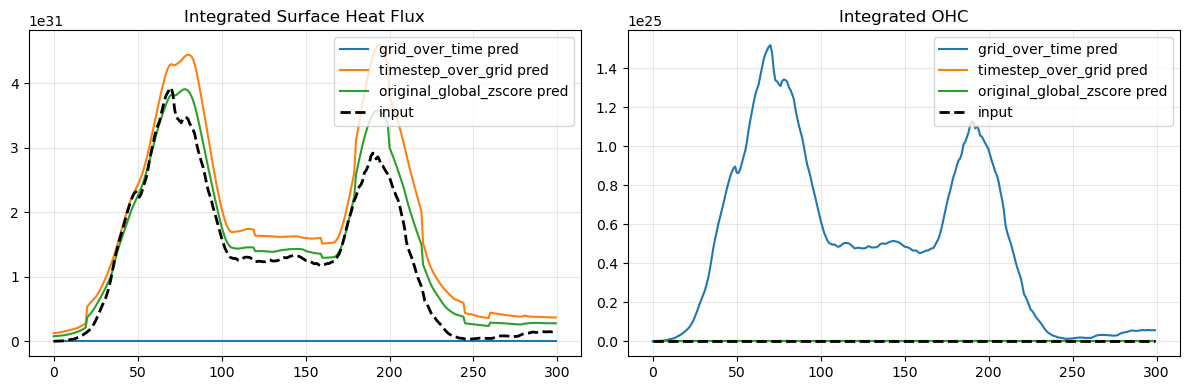

In [37]:
# Plot integrated timeseries: one observed curve plus one prediction per mode.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for mode in NORMALISATION_MODES:
    axes[0].plot(integrated_series_by_mode[mode]["SFX_pred_J"], label=f"{mode} pred")
    axes[1].plot(integrated_series_by_mode[mode]["OHC_pred_J"], label=f"{mode} pred")

# Observed input is mode-independent (same physical reference sample), so plot once.
reference_mode = NORMALISATION_MODES[0]
axes[0].plot(integrated_series_by_mode[reference_mode]["SFX_in_J"], "k--", linewidth=2, label="input")
axes[1].plot(integrated_series_by_mode[reference_mode]["OHC_in_J"], "k--", linewidth=2, label="input")

axes[0].set_title("Integrated Surface Heat Flux")
axes[1].set_title("Integrated OHC")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
